

**The Hybrid Equation: KNOWN PHYSICS + UDE**
$$ C_m \frac{dV}{dt} = I_{ext} - \mathbf{NN(V)} - I_{K}(V) - I_{L}(V) $$


In [1]:
using Lux, SciMLSensitivity, DifferentialEquations, Zygote, Optimisers, Plots
using Optimization, OptimizationOptimisers, ComponentArrays, Random, Statistics, Printf, JLD2

Random.seed!(1234)

TaskLocalRNG()

In [2]:
data = @load"Data/synthetic_data/noise_0_hh_2d_model.jld"


3-element Vector{Symbol}:
 :t
 :V
 :n

In [3]:
using Plots
theme(:dark)

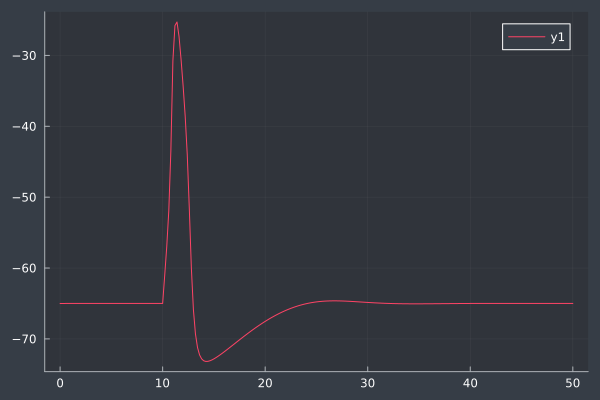

In [4]:

V = V[1:2:501]
t=t[1:2:501]
n=n[1:2:501]
plot(t,V)

In [5]:
# This is actually voltage data, not time
V = Float32.(V)

# Create time vector (assuming 0.1 ms timesteps over 50 ms)
t = Float32.(t)
n=Float32.(t)




251-element Vector{Float32}:
  0.0
  0.2
  0.4
  0.6
  0.8
  1.0
  1.2
  1.4
  1.6
  1.8
  2.0
  2.2
  2.4
  ⋮
 47.8
 48.0
 48.2
 48.4
 48.6
 48.8
 49.0
 49.2
 49.4
 49.6
 49.8
 50.0

In [ ]:
# plot(t,V)

In [6]:
const Cm = 1.0f0
const g_L = 0.3f0
const E_L = -54.387f0
const g_K = 36.0f0
const E_K = -77.0f0

# Rate functions using Float32 literals
alpha_n(V) = 0.01f0 * (V + 55.0f0) / (1.0f0 - exp(-(V + 55.0f0) / 10.0f0))
beta_n(V)  = 0.125f0 * exp(-(V + 65.0f0) / 80.0f0)


# Dynamics helpers
n_inf(V) = alpha_n(V) / (alpha_n(V) + beta_n(V))
tau_n(V) = 1.0f0 / (alpha_n(V) + beta_n(V))

tau_n (generic function with 1 method)

In [7]:
# Architecture: 1->16, 16->16, 16->1
nn = Lux.Chain(
    Lux.Dense(2 => 16, tanh),
    Lux.Dense(16 => 16, tanh),
    Lux.Dense(16 => 1)
)

Chain(
    layer_1 = Dense(2 => 16, tanh),               # 48 parameters
    layer_2 = Dense(16 => 16, tanh),              # 272 parameters
    layer_3 = Dense(16 => 1),                     # 17 parameters
)         # Total: 337 parameters,
          #        plus 0 states.

In [8]:


# Initialize parameters and state
rng = Random.default_rng()
p_init, st = Lux.setup(rng, nn)
p = ComponentArray(p_init) |> f32  # Parameters as a vector for the optimizer

println("Neural network parameters: ", length(p))

Neural network parameters: 337


In [9]:
# normalization
using Statistics
# ---> pseudocode
const V_mean = mean(V)
const V_std  = std(V)
# Create a normalized version of the ground truth ONCE
# (Normalized voltage is between -1 and 4)
norm_V = (V .- V_mean) ./ V_std

251-element Vector{Float32}:
 -0.068819575
 -0.068697184
 -0.068582796
 -0.068476416
 -0.06837919
 -0.06828997
 -0.0682099
 -0.0681367
 -0.06807264
 -0.06801659
 -0.06796741
 -0.06792509
 -0.06788962
  ⋮
 -0.068214476
 -0.06824193
 -0.06826824
 -0.06829111
 -0.068311706
 -0.068330005
 -0.06834716
 -0.06836089
 -0.06837347
 -0.06838377
 -0.06839178
 -0.06839864

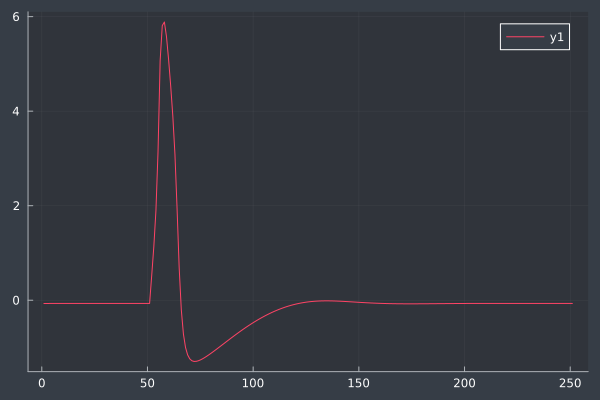

In [10]:
using Plots
theme(:dark)
plot(norm_V)

In [11]:
function Stimulus(t)
    return (t >= 10.0 && t <= 11.0) ? 20.0 : 0.0
end

Stimulus (generic function with 1 method)

In [ ]:


# Corrected UDE function for 2D Hodgkin-Huxley
function hodgkin_huxley_UDE!(du, u, p, t)
    V, n = u  # ✅ Unpack both state variables
    norm_V = (V-V_mean)/V_std
    # Neural network predicts sodium current
    pred_I_Na = ([norm_V, n], p, st)[1][1]
    
    # Known physics: Potassium & Leak currents
    I_K = g_K * (n^4) * (V - E_K)
    I_L = g_L * (V - E_L)
    I_ext = Stimulus(t) 

    # Dynamics for voltage
    du[1] = (I_ext - pred_I_Na - I_K - I_L) / Cm
    
    # Dynamics for potassium activation (known physics)
    du[2] = (n_inf(V) - n) / tau_n(V)
end

println("✅ UDE System Defined.")

✅ UDE System Defined.


In [13]:
# Calculate initial n value from steady-state
u0 = Float32.([V[1], n[1]])
tspan = (0.0f0, 30.0f0)



# Create ODE problem
prob_nn = ODEProblem(hodgkin_huxley_UDE!,  u0, tspan, p)



ODEProblem with uType Vector{Float32} and tType Float32. In-place: true
Non-trivial mass matrix: false
timespan: (0.0f0, 30.0f0)
u0: 2-element Vector{Float32}:
 -65.0
   0.0

In [14]:

const tstops = [10.0, 11.0]
function predict_ude(p)
    _prob = remake(prob_nn, p=p)  # ✅ Uses prob_nn, not prob
    
    sol = solve(_prob, Rodas5(), saveat=t,
                abstol=1e-5, reltol=1e-5,tstops=tstops,
                sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()))
end

predict_ude (generic function with 1 method)

In [15]:
# ...existing code...
function loss(θ, p)
    sol = predict_ude(θ)  # ✅ Get the solution object
    
    # Check for failed solve
    if sol.retcode != :Success
        return 1000.0f0  # Use Float32
    end
    
    # Extract the voltage prediction (first row of solution)
    # Convert ODESolution to a dense array before indexing to aid Zygote's AD
    pred_raw = sol[1, :] 
    
    # 1. Normalize the Prediction locally
    pred_norm = (pred_raw .- V_mean) ./ V_std
    
    # 2. Compare against Pre-Normalized Data
    current_loss = mean(abs2, pred_norm .- norm_V)
    
    return current_loss
end
# ...existing code...

loss (generic function with 1 method)

In [16]:
const SAVE_PATH = "UDE_2D_HH_best_params.jld2"

"UDE_2D_HH_best_params.jld2"

In [18]:

losses = Float32[]
min_loss = Inf32
best_params = deepcopy(p) # Initialize best_params with the initial parameters
# ...existing code...
function callback(state, l) 
    push!(losses, l)
    iter = length(losses)

    is_new_best = false
    # Check if current loss is a new minimum
    if l < min_loss
        global min_loss = l
        global best_params = deepcopy(state.u) # Store a copy of the parameters that achieved this new best loss
        is_new_best = true
    end

    # Save to file periodically (e.g., every 10 iterations) or when a new best loss is found.
    # This ensures the full `loss_history` is frequently persisted,
    # and `params` in the file always refer to the parameters for the `best_loss` found so far.
    if is_new_best || (iter % 10 == 0) 
        jldsave(SAVE_PATH; params=best_params, loss_history=losses, best_loss=min_loss)
    end

    # Print progress (using the same condition as before)
    if iter % 10 == 0 || is_new_best
        @printf("Iter %4d | Loss %.6f | Best %.6f\n", iter, l, min_loss)
    end

    return false  # Continue training
end


callback (generic function with 1 method)

In [19]:
using OptimizationOptimJL  

optf = OptimizationFunction(loss, Optimization.AutoZygote())
optprob = OptimizationProblem(optf, p)

println("✅ Optimization Problem Created")

✅ Optimization Problem Created


In [ ]:
println("\n=== Stage 1: Adam (lr=0.05) ===")
res1 = solve(optprob, OptimizationOptimisers.Adam(0.001f0),                                                              
             callback=callback, maxiters=2000)


=== Stage 1: Adam (lr=0.05) ===
Iter    1 | Loss 0.665262 | Best 0.665262
Iter   10 | Loss 11.629065 | Best 0.665262
Iter   11 | Loss 0.651156 | Best 0.651156
Iter   18 | Loss 0.650447 | Best 0.650447
Iter   20 | Loss 10.976829 | Best 0.650447
Iter   30 | Loss 254505.578125 | Best 0.650447
Iter   40 | Loss 213.246964 | Best 0.650447


In [85]:
l = @load("UDE_2D_HH_best_params.jld2")

3-element Vector{Symbol}:
 :params
 :loss_history
 :best_loss

In [86]:
length(loss_history)

34

In [87]:
P_pramas = params


ComponentVector{Float32}(layer_1 = (weight = Float32[0.8259658 1.933124; 1.610314 -0.22096343; … ; -0.8757216 0.21057484; 1.0839633 0.9321797], bias = Float32[-0.42519122, -0.5883637, 0.34153128, 0.39025617, -0.5870222, -0.31427446, 0.5311251, -0.29296684, 0.08239126, 0.008731088, -0.1712134, -0.5063226, -0.49740928, -0.5696536, 0.16444056, 0.040391643]), layer_2 = (weight = Float32[0.06940901 -0.24795505 … 0.5623943 -0.37676877; -0.27177247 -0.24839963 … 0.24672256 0.62528086; … ; 0.5142083 -0.04576399 … -0.6449307 -0.7402834; 0.53904086 0.67307234 … 0.48709947 0.33019388], bias = Float32[-0.071490325, -0.076608196, 0.12217766, 0.055924132, -0.16489339, -0.10822445, 0.03666674, -0.19645065, -0.08100203, -0.12376141, 0.13660425, 0.15013292, -0.24585, 0.009322564, 0.0365337, 0.25752312]), layer_3 = (weight = Float32[-0.29876852 0.17321709 … -0.08997886 -0.1068194], bias = Float32[-0.03567162]))

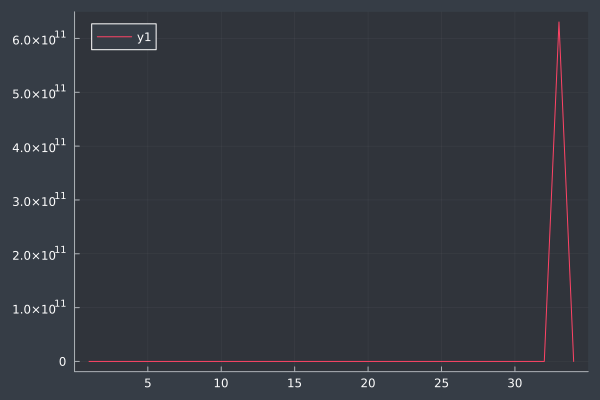

In [88]:
plot(loss_history)

In [89]:
# function predict_ude2(p)
#     _prob = remake(prob_nn, p=p)
#     solve(_prob, Rodas5P(), 
#           saveat=0.1, 
#           tstops=[10.0, 11.0, 30.0, 31.0], # Handle the 'Cliffs'
#           abstol=1e-6, reltol=1e-6,
#           sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP())) # Best for stiff HH [cite: 11, 200]
# end

In [90]:
# optprob_phase2 = remake(optprob,u0=P_pramas)
# println("\n=== Stage 2: High-Intensity Adam (lr=0.01) ===")
# res2 = solve(optprob_phase2, 
#              OptimizationOptimisers.Adam(0.01f0), 
#              callback=callback, 
#              maxiters=100)